<a href="https://colab.research.google.com/github/samiksha2509/Samiksha_MacDonalds/blob/main/Indian_automoble_buying_behavour_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
# Load the dataset
data_path = '/content/Indian automoble buying behavour study 1.0.csv'  # Update with actual file path
df = pd.read_csv(data_path)

In [3]:
# Initial exploration
print("Dataset Overview:\n", df.head())
print("\nDataset Info:")
df.info()
print("\nDescriptive Statistics:\n", df.describe())

Dataset Overview:
    Age Profession Marrital Status      Education  No of Dependents  \
0   27   Salaried          Single  Post Graduate                 0   
1   35   Salaried         Married  Post Graduate                 2   
2   45   Business         Married       Graduate                 4   
3   41   Business         Married  Post Graduate                 3   
4   31   Salaried         Married  Post Graduate                 2   

  Personal loan House Loan Wife Working   Salary  Wife Salary  Total Salary  \
0           Yes         No           No   800000            0        800000   
1           Yes        Yes          Yes  1400000       600000       2000000   
2           Yes        Yes           No  1800000            0       1800000   
3            No         No          Yes  1600000       600000       2200000   
4           Yes         No          Yes  1800000       800000       2600000   

     Make    Price  
0     i20   800000  
1    Ciaz  1000000  
2  Duster  1200000  
3

In [4]:
# Data Preprocessing
# Convert categorical variables to numerical
categorical_columns = ['Profession', 'Marrital Status', 'Education', 'Make', 'Wife Working']
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [5]:
# Handle missing values
df_encoded = df_encoded.dropna()

In [6]:
# Standardize numerical features
numerical_features = ['Age', 'Salary', 'Wife Salary', 'Total Salary', 'Price']
scaler = StandardScaler()
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

In [7]:
# Segmentation using K-Means Clustering
X = df_encoded.drop(columns=['Personal loan', 'House Loan'])  # Features for clustering

In [8]:
# Find the optimal number of clusters using the Elbow Method
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

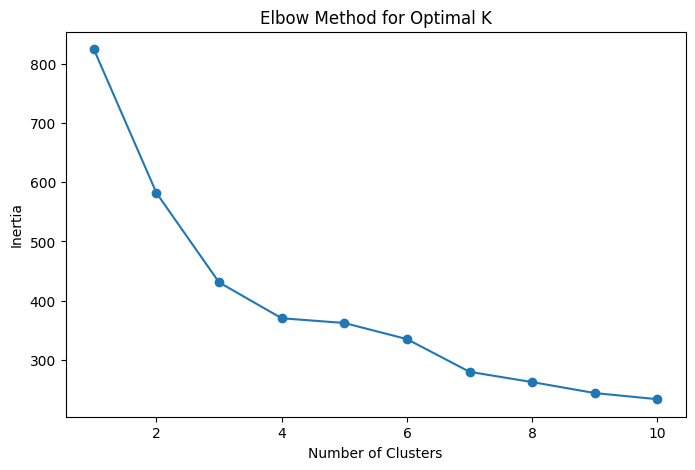

In [9]:
# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [10]:
# Apply K-Means with optimal K (assuming optimal K = 3 for this example)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)
df['Cluster'] = clusters

In [12]:
# Analyze Clusters
# Only include numeric features for calculating the mean
cluster_summary = df.groupby('Cluster').agg({col: 'mean' for col in df.select_dtypes(include=np.number).columns})
print("Cluster Summary:\n", cluster_summary)

Cluster Summary:
                Age  No of Dependents        Salary   Wife Salary  \
Cluster                                                            
0        29.434783          0.086957  1.226087e+06  2.695652e+05   
1        40.481481          2.592593  2.451852e+06  1.196296e+06   
2        37.244898          2.938776  1.581633e+06  2.938776e+05   

         Total Salary         Price  Cluster  
Cluster                                       
0        1.495652e+06  1.083043e+06      0.0  
1        3.648148e+06  1.648148e+06      1.0  
2        1.875510e+06  9.959184e+05      2.0  


In [13]:
# Visualize Clusters using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

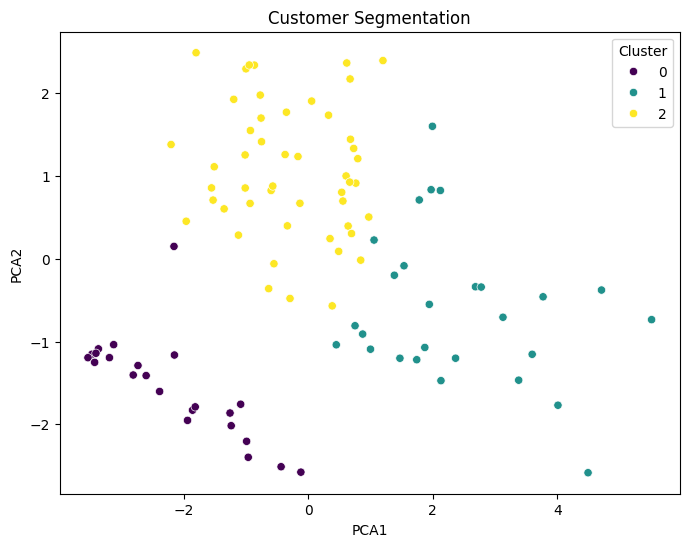

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='viridis')
plt.title('Customer Segmentation')
plt.show()

In [17]:
# Strategy Formulation
# Identify segments most likely to adopt EVs
# Example criteria: High income, younger age, no house loans
# Check if "House Loan" or "Personal loan" is in the cluster_summary columns
# If not, consider the original 'df' DataFrame or adjust criteria accordingly
if 'House Loan' in cluster_summary.columns:
    potential_segments = cluster_summary[(cluster_summary['Age'] < 0) & (cluster_summary['Salary'] > 0) & (cluster_summary['House Loan'] < 0)]
elif 'Personal loan' in cluster_summary.columns:
    # Assume 'Personal loan' is a proxy for 'House Loan' if it exists
    potential_segments = cluster_summary[(cluster_summary['Age'] < 0) & (cluster_summary['Salary'] > 0) & (cluster_summary['Personal loan'] < 0)]
else:
    print("Neither 'House Loan' nor 'Personal loan' found in cluster_summary. Adjust criteria or use original DataFrame 'df'.")
    potential_segments = pd.DataFrame()  # Create an empty DataFrame

print("Potential EV Adopter Segments:\n", potential_segments)

Neither 'House Loan' nor 'Personal loan' found in cluster_summary. Adjust criteria or use original DataFrame 'df'.
Potential EV Adopter Segments:
 Empty DataFrame
Columns: []
Index: []


In [18]:
# Strategy
print("\nFeasible Market Entry Strategy:")
print("1. Focus on younger professionals with higher disposable income.")
print("2. Provide financing options for EV purchases.")
print("3. Target urban areas where charging infrastructure is more likely to develop.")
print("4. Emphasize environmental benefits and long-term cost savings.")


Feasible Market Entry Strategy:
1. Focus on younger professionals with higher disposable income.
2. Provide financing options for EV purchases.
3. Target urban areas where charging infrastructure is more likely to develop.
4. Emphasize environmental benefits and long-term cost savings.
